# HD Integrated Visium Interactive Suite (HiVis) - Single-cell aggregation
This Notebook describes how to import single-cell segmentation from Qupath into HiVis. Segmentation can be both Stardist and Cellpose.

We will use the HiVis object from [previous notebook](https://github.com/roynov01/HiVis/blob/main/tutorials/2_annotations_and_classifiers.ipynb).

We will also use some plots, which will be covered in detail in next notebooks.

To see a details explanation and parameters for each function, visit the [documentation](https://hivis.readthedocs.io/latest/).

In [1]:
import os
import sys
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from HiVis import HiVis

sys.path.append(os.path.abspath(".."))

path = 'output/mouse_intestine.pkl'
si = HiVis.load(path) 

C:\Users\royno.WISMAIN\AppData\Local\anaconda3\envs\hivis1\Lib\site-packages\scanpy\_utils\__init__.py:35: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
C:\Users\royno.WISMAIN\AppData\Local\anaconda3\envs\hivis1\Lib\site-packages\scanpy\__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
C:\Users\royno.WISMAIN\AppData\Local\anaconda3\envs\hivis1\Lib\site-packages\scanpy\readwrite.py:15: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


We can aggregate the spots into single-cells or single-nuclei.

In this example, the segmentation is performed in Qupath via Stardist with expansion of nuclei.

Tutorial for the segmentation can be seen in the [readme file]().

In this tutorial we will run the segmentation on a small subset of the tissue, to conserve time and avoid large files. For that, we export the image from a cropped HiVis, and import it into Qupath.

In this case we will use "mouse_intestine_subset_fullres.tif", "mouse_intestine_subset_tissue_positions.csv", "mouse_intestine_subset_scalefactors_json.json" for the Stardist script.

In [2]:
sub = si.crop(xlim=(0, 400), ylim=(3300, 3700))
_ = sub.export_images()

Aggregation [intestine_part] is empty


In [3]:
segmentation_path = "qupath/mouse_intestine_subset_fullres_detections.csv"
segmentation = pd.read_csv(segmentation_path, sep="\t")
geojson_path = r"qupath/mouse_intestine_subset_fullres_cells.geojson"
sub.agg_cells(segmentation, name="SC", obs2add=["Area µm^2","Length µm"], obs2agg=["intestine_part","muscle_villi_classifier"],geojson_path=geojson_path)

[Splitting name column and merging metadata]


Aggregating spots expression: 100%|███████████████████████████████████████████████| 2515/2515 [00:03<00:00, 712.17it/s]


[Importing geometry]
Number of shapes (7590) isn't the same as the number of cells in adata (2515)


The aggregation by single cells usually takes few minutes.

Notice that we can add measurements from qupath (color intensity, diameter of cells etc.) to to HiVis adata, and also aggregate metadata from the HiVis.
In this example, we will transfer the annotations and the classifier.

We can also specify the path of the GeoJSON, to have the geometry of the single-cells (usefull for plotting). We can also skip this, and add the geometry later, by calling Agg.import_geometry(geojson_path).

We can import the shapes seperetly

In [4]:
geojson_path = r"qupath/mouse_intestine_subset_fullres_cells.geojson"
sub.agg["SC"].import_geometry(geojson_path)

[Importing geometry]
Number of shapes (7590) isn't the same as the number of cells in adata (2515)
Geometry column already exists, overwriting...


We can acess the new Aggregation 

In [5]:
print(sub.agg["SC"].name)
print(sub.agg["SC"].shape) # cells * genes

mouse_intestine_subset_SC
(2515, 3222)


The Aggregation is linked to the HiVis object

In [6]:
sub.agg["SC"].viz

# mouse_intestine_subset #
	Organism: mouse
	Size: 31481 x 3222

obs: in_tissue, array_row, array_col, pxl_row_in_fullres, pxl_col_in_fullres, nUMI, mito_sum, nUMI_log10, mito_percent_log10, Apob_positive, muscle_villi_classifier, intestine_part, intestine_part_id, pxl_col_in_lowres, pxl_row_in_lowres, pxl_col_in_highres, pxl_row_in_highres, um_x, um_y, Cell_ID_SC, InNuc

var: gene_ids, feature_types, genome, nUMI_gene, nUMI_gene_log10

Aggregations:
[SC]	shape: 2515 x 3222

We can plot the cells (detailed tutorial is in next notebooks)

C:\Users\royno.WISMAIN\AppData\Local\anaconda3\envs\hivis1\Lib\site-packages\HiVis\HiVis_plot.py:833: RuntimeWarning: invalid value encountered in cast
  is_int = np.issubdtype(values.dtype, np.integer) or np.allclose(values, values.astype(int))


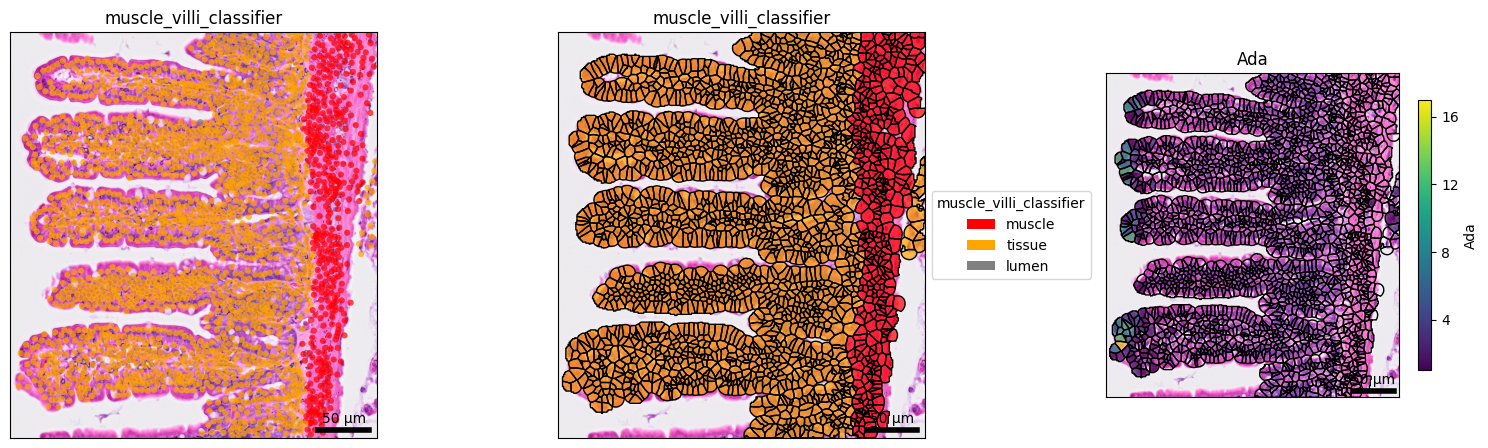

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = {"immune":"blue", "lumen":"gray", "muscle":"red", "tissue":"orange"}
sub.agg["SC"].plot.spatial("muscle_villi_classifier",  ax=axes[0], cmap=colors, legend=False, alpha=0.7, size=20)
sub.agg["SC"].plot.cells("muscle_villi_classifier",  ax=axes[1],alpha=0.7,  cmap=colors)
sub.agg["SC"].plot.cells("Ada",  ax=axes[2],alpha=0.7)

plt.tight_layout()

## Single-cell analysis and clustering using external tools
Since the data is stored as AnnData, we can work on the adata with other tools, such as [Scanpy](https://scanpy.readthedocs.io/en/stable/) or [Squidpy](https://squidpy.readthedocs.io/en/stable/). If you subset a copy of the adata (for example if you perform UMAP with only highly variable genes, or subset specific cells), you can merge it with the Agg.adata by using Agg.merge().

Be aware of normalization/log transformation of the data, consider working with layers. All plots of and analysis methods accept a *layer* argument. 

Lets perform basic cell-type clustering and visualize the celltypes with spatial plots. 

For clustering we will use sc.tl.leiden, which requires installation of two packages.

In [8]:
!pip install igraph leidenalg

C:\Users\royno.WISMAIN\AppData\Local\anaconda3\envs\hivis1\Lib\site-packages\scanpy\preprocessing\_pca\__init__.py:245: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  Version(ad.__version__) < Version("0.9")
C:\Users\royno.WISMAIN\AppData\Local\anaconda3\envs\hivis1\Lib\site-packages\scanpy\neighbors\__init__.py:423: FutureWarning: Use obsm (e.g. `k in adata.obsm` or `adata.obsm.keys() | {'u'}`) instead of AnnData.obsm_keys, AnnData.obsm_keys is deprecated and will be removed in the future.
  if "X_diffmap" in adata.obsm_keys():
C:\Users\royno.WISMAIN\AppData\Local\Temp\ipykernel_54268\4105087937.py:14: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_sc,resolution=0.7,random_state=0,n_iterations=2,directed=False)


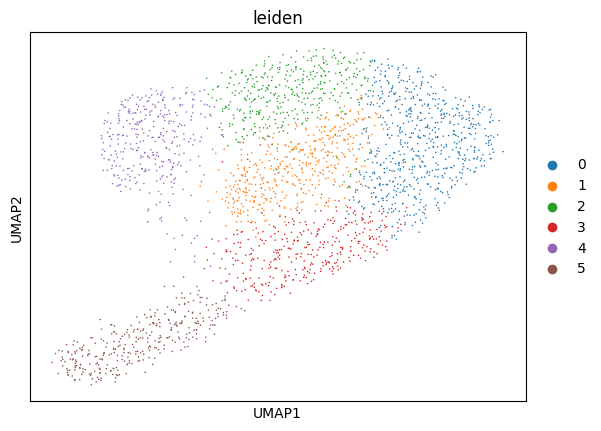

In [9]:
import scanpy as sc

adata_sc = sub.agg["SC"].adata.copy()
sc.pp.normalize_total(adata_sc, target_sum=1e4)
adata_sc.var["expression_mean"] = np.array(adata_sc.X.mean(axis=0)).flatten()/1e4
adata_sc.var["expression_max"] =  np.array(adata_sc.X.max(axis=0).toarray()).flatten()/1e4
sc.pp.log1p(adata_sc)
sc.pp.highly_variable_genes(adata_sc, n_top_genes=1000)
adata_sc = adata_sc[:,(adata_sc.var['highly_variable'] == True) ].copy()
sc.pp.scale(adata_sc, max_value=10)
sc.tl.pca(adata_sc, svd_solver="arpack")
sc.pp.neighbors(adata_sc, n_neighbors=15, n_pcs=20) 
sc.tl.umap(adata_sc)
sc.tl.leiden(adata_sc,resolution=0.7,random_state=0,n_iterations=2,directed=False)
sc.pl.umap(adata_sc,color="leiden",size=5)

We can merge the "leiden" obs to our object

In [10]:
sub.agg["SC"].merge(adata_sc,obs="leiden")
sub.agg["SC"]["leiden"]

array(['5', '3', '1', ..., '0', '5', '0'], shape=(2515,), dtype=object)

We can plot the clusters.  Optionally we can order the column first, so the colors will be the same in all plots.

In [11]:
sub.agg["SC"].adata.obs["leiden"] = sub.agg["SC"].adata.obs["leiden"].cat.reorder_categories(sorted(sub.agg["SC"].adata.obs["leiden"].cat.categories, key=str), ordered=True)
sub.agg["SC"].adata.obs["leiden"]

Cell_ID_SC
00051825-5b90-4a91-8f0e-00f630ed5a92    5
00085c90-58ff-434f-ba5a-8665ff1811ee    3
000e9178-d506-4064-9f77-ff0b994add6e    1
001e8a45-e8cb-4b0d-9f12-fa7cacd6a513    4
0022cdd9-9147-47ac-a682-a032fd356625    1
                                       ..
ff5b292b-cf36-4f08-914b-7ddc8edadc19    4
ff79548d-2e34-4f72-babd-e4075277b1da    4
ffef2b14-f6d8-41d4-8212-53000de46473    0
fff4e317-c285-44e3-90a3-25318678b853    5
fffc7dda-4ca6-436d-8e4f-7d743a6c0962    0
Name: leiden, Length: 2515, dtype: category
Categories (6, object): ['0' < '1' < '2' < '3' < '4' < '5']

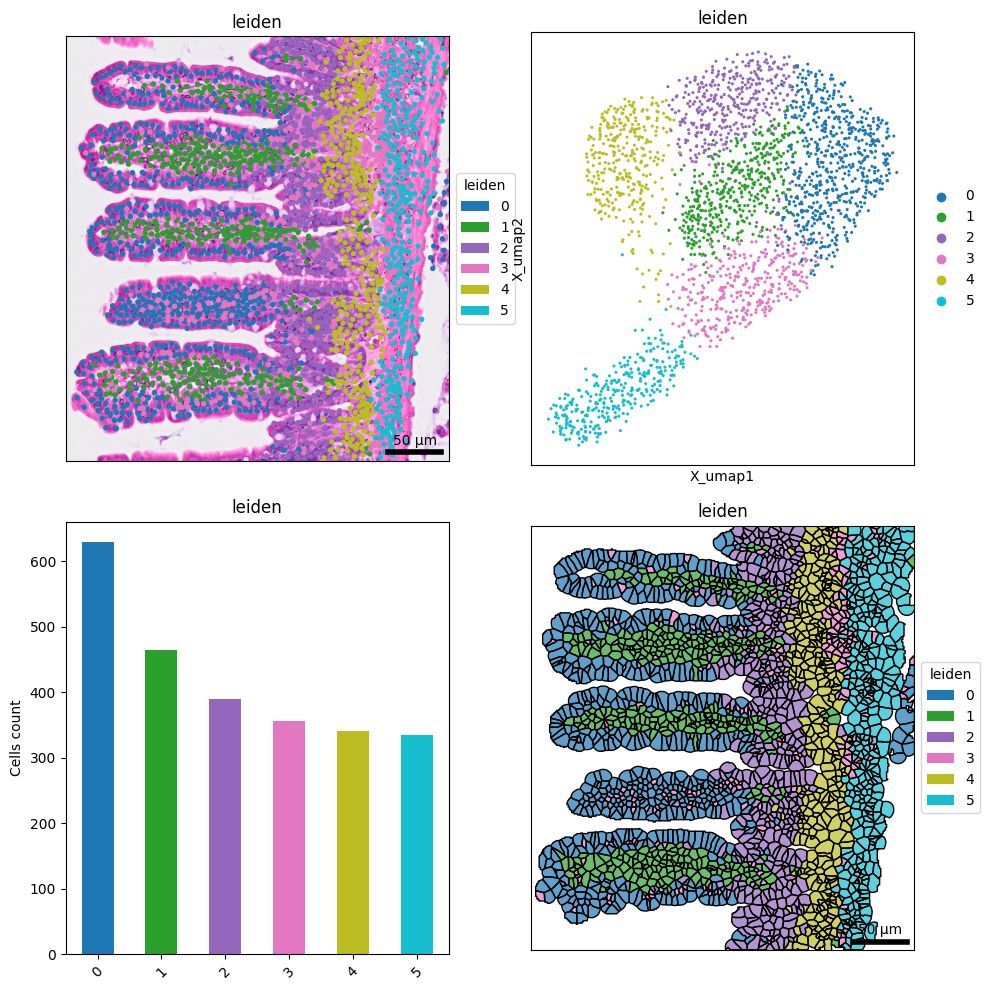

In [12]:
cmap = "tab10"
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()
sub.agg["SC"].plot.spatial("leiden", size=15, ax=axes[0],cmap=cmap)
sub.agg["SC"].plot.umap("leiden",size=20, ax=axes[1],cmap=cmap)
sub.agg["SC"].plot.hist("leiden", ax=axes[2], ylab="Cells count",cmap=cmap,cropped=True)
sub.agg["SC"].plot.cells("leiden",  ax=axes[3],cmap=cmap, image=False)

plt.tight_layout()

## Transfer information from cells to bins
Since the Aggregation is linked to the HiVis object, we can transfer information from the Aggregation back to HiVis. Lets transfer the Leiden cluster, so we know the cluster of each spot.

In [13]:
sub.agg["SC"].sync("leiden")
sub.columns # leiden is added

Index(['in_tissue', 'array_row', 'array_col', 'pxl_row_in_fullres',
       'pxl_col_in_fullres', 'nUMI', 'mito_sum', 'nUMI_log10',
       'mito_percent_log10', 'Apob_positive', 'muscle_villi_classifier',
       'intestine_part', 'intestine_part_id', 'pxl_col_in_lowres',
       'pxl_row_in_lowres', 'pxl_col_in_highres', 'pxl_row_in_highres', 'um_x',
       'um_y', 'Cell_ID_SC', 'InNuc', 'leiden'],
      dtype='object')

## Subsetting, copying and export
Similar to subsetting of HiVis, we can subset and copy Aggregations

In [14]:
cluster_0 = sub.agg["SC"]["leiden"] == "0"
sub.agg["cluster_0"] = sub.agg["SC"][cluster_0,:]
sub.agg["cluster_0"].rename("mouse_intestine_SC_clust0", full=True, new_out_path=True)

In [15]:
sub.agg["cluster_0_copy"] = sub.agg["cluster_0"].copy(new_name="copy")
sub

# mouse_intestine_subset #
	Organism: mouse
	Size: 31481 x 3222

obs: in_tissue, array_row, array_col, pxl_row_in_fullres, pxl_col_in_fullres, nUMI, mito_sum, nUMI_log10, mito_percent_log10, Apob_positive, muscle_villi_classifier, intestine_part, intestine_part_id, pxl_col_in_lowres, pxl_row_in_lowres, pxl_col_in_highres, pxl_row_in_highres, um_x, um_y, Cell_ID_SC, InNuc, leiden

var: gene_ids, feature_types, genome, nUMI_gene, nUMI_gene_log10

Aggregations:
[SC]	shape: 2515 x 3222
[cluster_0]	shape: 629 x 3222
[cluster_0_copy]	shape: 629 x 3222

And save, for later use

In [16]:
sub.save()

SAVING [mouse_intestine_subset]


'output/mouse_intestine_subset.pkl'